# Módulo 19 — Notebook 0: Fundamentos de Señales Biomédicas

---

## ¿Qué es una señal biomédica?

Una **señal biomédica** es cualquier variable fisiológica medible que varía en el tiempo:  
el voltaje eléctrico del corazón, la presión arterial, la actividad muscular, el nivel de oxígeno en sangre.

En el dominio digital, una señal es simplemente una **lista de números** tomados a intervalos regulares.

```
Señal continua (analógica):   ∿∿∿∿∿∿∿∿∿
                                  ↓ muestreo a fs Hz
Señal discreta (digital):    [0.1, 0.3, 0.8, 1.0, 0.7, 0.2, ...]
                              muestra 0  1    2    3    4    5
```

**Frecuencia de muestreo (fs):** cuántas muestras se toman por segundo [Hz].  
**Teorema de Nyquist:** para capturar correctamente una frecuencia `f`, necesitas `fs ≥ 2f`.

## Señales Biomédicas Principales

| Señal | Rango de frecuencia | Amplitud típica | fs recomendada |
|-------|-------------------|-----------------|---------------|
| **ECG** | 0.05 – 100 Hz | 0.5 – 4 mV | ≥ 500 Hz |
| **EEG** | 0.5 – 100 Hz | 10 – 100 μV | ≥ 256 Hz |
| **EMG** | 20 – 500 Hz | 0.1 – 10 mV | ≥ 2000 Hz |
| **Presión arterial** | 0 – 30 Hz | 80 – 120 mmHg | ≥ 100 Hz |
| **SpO₂ (PPG)** | 0.5 – 5 Hz | depende del sensor | ≥ 50 Hz |
| **Respiración** | 0.1 – 0.8 Hz (6-48 rpm) | variable | ≥ 25 Hz |

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import matplotlib

# Configuración global de gráficas
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['figure.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['axes.labelcolor'] = '#c9d1d9'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['text.color'] = '#c9d1d9'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

print("Bibliotecas cargadas ✓")
print(f"matplotlib: {matplotlib.__version__}")

Bibliotecas cargadas ✓
matplotlib: 3.10.7


## 1. Modelado Matemático del ECG

Un electrocardiograma (ECG) registra la actividad eléctrica del corazón.  
Cada ciclo cardíaco contiene ondas características:

```
     R
     |
  P  |       T
 /\  |      /\
/  \ |     /  \
     |\   /
     | \ /
     |  S
     Q
──────────────────▶ tiempo
  P-R  QRS  S-T
```

Cada onda se modela con una **función gaussiana**: `A · exp(-(t - μ)² / (2σ²))`

In [ ]:
def gaussiana(t, amplitud, centro, ancho):
    """Función gaussiana para modelar ondas cardíacas.
    
    Args:
        t (float): tiempo normalizado [0, 1] dentro del ciclo cardíaco
        amplitud (float): altura de la onda [mV]
        centro (float): posición temporal de la onda
        ancho (float): duración de la onda (σ)
        
    Returns:
        float: valor de la onda en el tiempo t
    """
    return amplitud * math.exp(-((t - centro) ** 2) / (2 * ancho ** 2))


def ecg_sintetico(t, fc=72, ruido=0.02):
    """Genera un valor de ECG sintético en el tiempo t.
    
    Modela un ritmo sinusal normal usando 5 ondas gaussianas
    que representan P, Q, R, S y T.
    
    Args:
        t (float): tiempo en segundos
        fc (float): frecuencia cardíaca en lpm (latidos por minuto)
        ruido (float): desviación estándar del ruido gaussiano
        
    Returns:
        float: voltaje del ECG en mV
    """
    periodo = 60.0 / fc       # duración de un ciclo cardíaco [s]
    t_ciclo = (t % periodo) / periodo   # posición normalizada [0, 1] en el ciclo

    señal = 0.0
    # Onda P (despolarización auricular)
    señal += gaussiana(t_ciclo, 0.15, 0.18, 0.025)
    # Onda Q (inicio de despolarización ventricular — negativa)
    señal -= gaussiana(t_ciclo, 0.10, 0.42, 0.010)
    # Onda R (despolarización ventricular — pico principal)
    señal += gaussiana(t_ciclo, 1.00, 0.46, 0.008)
    # Onda S (despolarización septal — negativa)
    señal -= gaussiana(t_ciclo, 0.22, 0.50, 0.008)
    # Onda T (repolarización ventricular)
    señal += gaussiana(t_ciclo, 0.30, 0.68, 0.035)

    # Ruido fisiológico (artefactos de movimiento, interferencia)
    señal += random.gauss(0, ruido)
    return señal



Señal ECG generada: 5000 muestras
Duración: 10 s   |   fs = 500 Hz   |   FC = 72 lpm
Amplitud máxima: 1.025 mV   |   Mínima: -0.249 mV


In [4]:
# Generar 10 segundos de ECG a 500 Hz
FS = 500          # frecuencia de muestreo [Hz]
DURACION = 10     # segundos
FC = 72           # frecuencia cardíaca [lpm]


In [7]:
FS

500

In [9]:
max([i for i in range(FS * DURACION)])

4999

In [6]:

tiempo = [i / FS for i in range(FS * DURACION)]
tiempo 


[0.0,
 0.002,
 0.004,
 0.006,
 0.008,
 0.01,
 0.012,
 0.014,
 0.016,
 0.018,
 0.02,
 0.022,
 0.024,
 0.026,
 0.028,
 0.03,
 0.032,
 0.034,
 0.036,
 0.038,
 0.04,
 0.042,
 0.044,
 0.046,
 0.048,
 0.05,
 0.052,
 0.054,
 0.056,
 0.058,
 0.06,
 0.062,
 0.064,
 0.066,
 0.068,
 0.07,
 0.072,
 0.074,
 0.076,
 0.078,
 0.08,
 0.082,
 0.084,
 0.086,
 0.088,
 0.09,
 0.092,
 0.094,
 0.096,
 0.098,
 0.1,
 0.102,
 0.104,
 0.106,
 0.108,
 0.11,
 0.112,
 0.114,
 0.116,
 0.118,
 0.12,
 0.122,
 0.124,
 0.126,
 0.128,
 0.13,
 0.132,
 0.134,
 0.136,
 0.138,
 0.14,
 0.142,
 0.144,
 0.146,
 0.148,
 0.15,
 0.152,
 0.154,
 0.156,
 0.158,
 0.16,
 0.162,
 0.164,
 0.166,
 0.168,
 0.17,
 0.172,
 0.174,
 0.176,
 0.178,
 0.18,
 0.182,
 0.184,
 0.186,
 0.188,
 0.19,
 0.192,
 0.194,
 0.196,
 0.198,
 0.2,
 0.202,
 0.204,
 0.206,
 0.208,
 0.21,
 0.212,
 0.214,
 0.216,
 0.218,
 0.22,
 0.222,
 0.224,
 0.226,
 0.228,
 0.23,
 0.232,
 0.234,
 0.236,
 0.238,
 0.24,
 0.242,
 0.244,
 0.246,
 0.248,
 0.25,
 0.252,
 0.254,
 0.25

In [10]:

ecg = [ecg_sintetico(t, fc=FC) for t in tiempo]

print(f"Señal ECG generada: {len(ecg)} muestras")
print(f"Duración: {DURACION} s   |   fs = {FS} Hz   |   FC = {FC} lpm")
print(f"Amplitud máxima: {max(ecg):.3f} mV   |   Mínima: {min(ecg):.3f} mV")

Señal ECG generada: 5000 muestras
Duración: 10 s   |   fs = 500 Hz   |   FC = 72 lpm
Amplitud máxima: 1.026 mV   |   Mínima: -0.239 mV


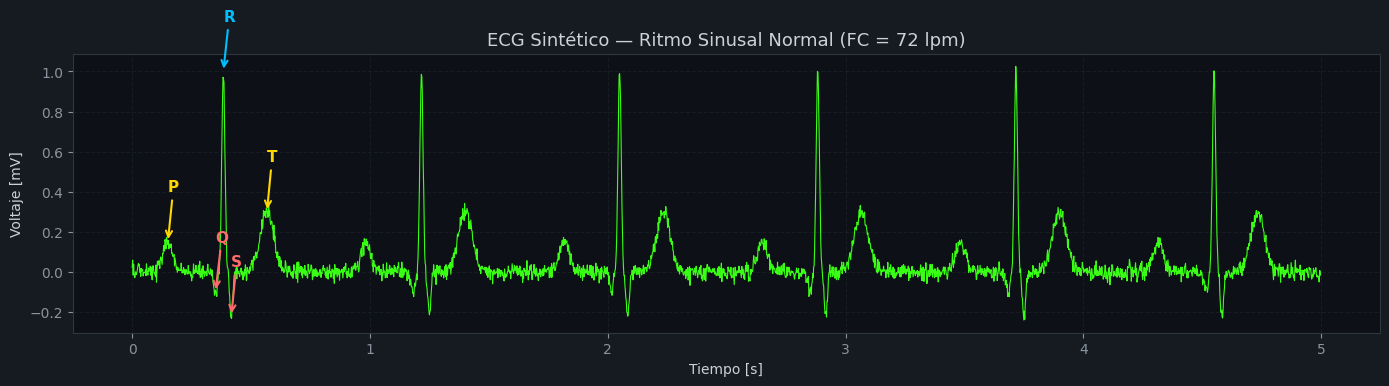

In [11]:
# Graficar los primeros 5 segundos del ECG
muestras_5s = FS * 5

fig, ax = plt.subplots()
ax.plot(tiempo[:muestras_5s], ecg[:muestras_5s], color='#39ff14', linewidth=0.8)
ax.set_title('ECG Sintético — Ritmo Sinusal Normal (FC = 72 lpm)', fontsize=13)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Voltaje [mV]')
ax.grid(True)

# Anotar las ondas en el primer ciclo
# Período = 60/72 ≈ 0.833 s
periodo = 60 / FC
for onda, t_rel, y_ref, color_ann in [
    ('P', 0.18 * periodo, 0.15, '#ffd700'),
    ('Q', 0.42 * periodo, -0.1, '#ff6b6b'),
    ('R', 0.46 * periodo, 1.0,  '#00bfff'),
    ('S', 0.50 * periodo, -0.22, '#ff6b6b'),
    ('T', 0.68 * periodo, 0.30,  '#ffd700'),
]:
    ax.annotate(onda, xy=(t_rel, y_ref), xytext=(t_rel, y_ref + 0.25),
                fontsize=11, color=color_ann, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color_ann, lw=1.5))

plt.tight_layout()
plt.show()

## 2. Señal EEG — Bandas de Frecuencia Cerebral

El EEG registra la actividad eléctrica del cerebro.  
Se compone de diferentes **bandas de frecuencia** que corresponden a estados cognitivos:

| Banda | Frecuencia | Estado asociado | Amplitud |
|-------|-----------|-----------------|----------|
| **Delta** (δ) | 0.5 – 4 Hz | Sueño profundo | Alta |
| **Theta** (θ) | 4 – 8 Hz | Somnolencia, meditación | Media |
| **Alpha** (α) | 8 – 13 Hz | Relajación, ojos cerrados | Media |
| **Beta** (β) | 13 – 30 Hz | Alerta, concentración | Baja |
| **Gamma** (γ) | > 30 Hz | Procesamiento cognitivo alto | Muy baja |

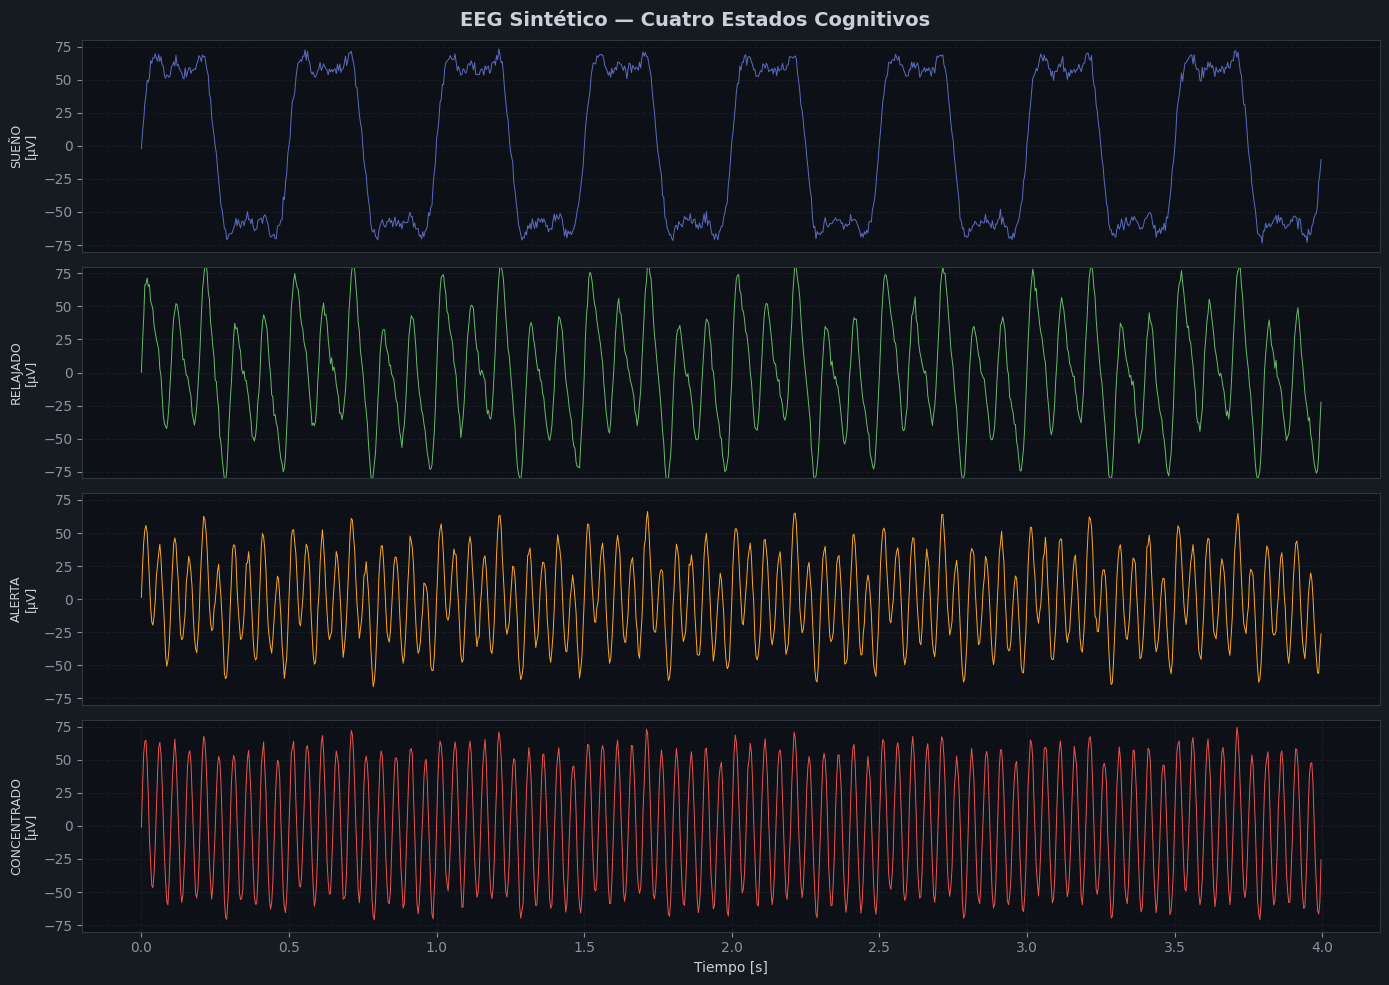

In [16]:
def eeg_sintetico(t, estado="relajado", ruido=0.05):
    """Genera un valor de EEG sintético según el estado cognitivo.
    
    Args:
        t (float): tiempo en segundos
        estado (str): 'sueño', 'relajado', 'alerta', 'concentrado'
        ruido (float): nivel de ruido gaussiano
        
    Returns:
        float: voltaje del EEG en μV
    """
    pi2 = 2 * math.pi
    
    # Amplitudes por estado (cada estado activa distintas bandas)
    amplitudes = {
        "sueño":       {"delta": 1.5, "theta": 0.5, "alfa": 0.2, "beta": 0.05},
        "relajado":    {"delta": 0.3, "theta": 0.4, "alfa": 1.0, "beta": 0.3},
        "alerta":      {"delta": 0.1, "theta": 0.2, "alfa": 0.3, "beta": 0.8},
        "concentrado": {"delta": 0.1, "theta": 0.1, "alfa": 0.1, "beta": 1.2},
    }
    amp = amplitudes.get(estado, amplitudes["relajado"])
    
    señal = (
        amp["delta"] * math.sin(pi2 * 2   * t) +    # δ: 2 Hz
        amp["theta"] * math.sin(pi2 * 6   * t) +    # θ: 6 Hz
        amp["alfa"]  * math.sin(pi2 * 10  * t) +    # α: 10 Hz
        amp["beta"]  * math.sin(pi2 * 20  * t)      # β: 20 Hz
    )
    señal += random.gauss(0, ruido)
    return señal * 50   # escalar a μV


# Graficar los 4 estados del EEG
FS_EEG = 256
dur_eeg = 4
t_eeg = [i / FS_EEG for i in range(FS_EEG * dur_eeg)]

estados = ["sueño", "relajado", "alerta", "concentrado"]
colores = ["#5c6bc0", "#66bb6a", "#ffa726", "#ef5350"]

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('EEG Sintético — Cuatro Estados Cognitivos', fontsize=14, fontweight='bold')

for i, (estado, color) in enumerate(zip(estados, colores)):
    señal_eeg = [eeg_sintetico(t, estado=estado) for t in t_eeg]
    axes[i].plot(t_eeg, señal_eeg, color=color, linewidth=0.7)
    axes[i].set_ylabel(f'{estado.upper()}\n[μV]', fontsize=9)
    axes[i].set_ylim(-80, 80)
    axes[i].grid(True)
    if i < 3:
        axes[i].set_xticks([])

axes[-1].set_xlabel('Tiempo [s]')
plt.tight_layout()
plt.show()

## 3. Señal EMG — Actividad Muscular

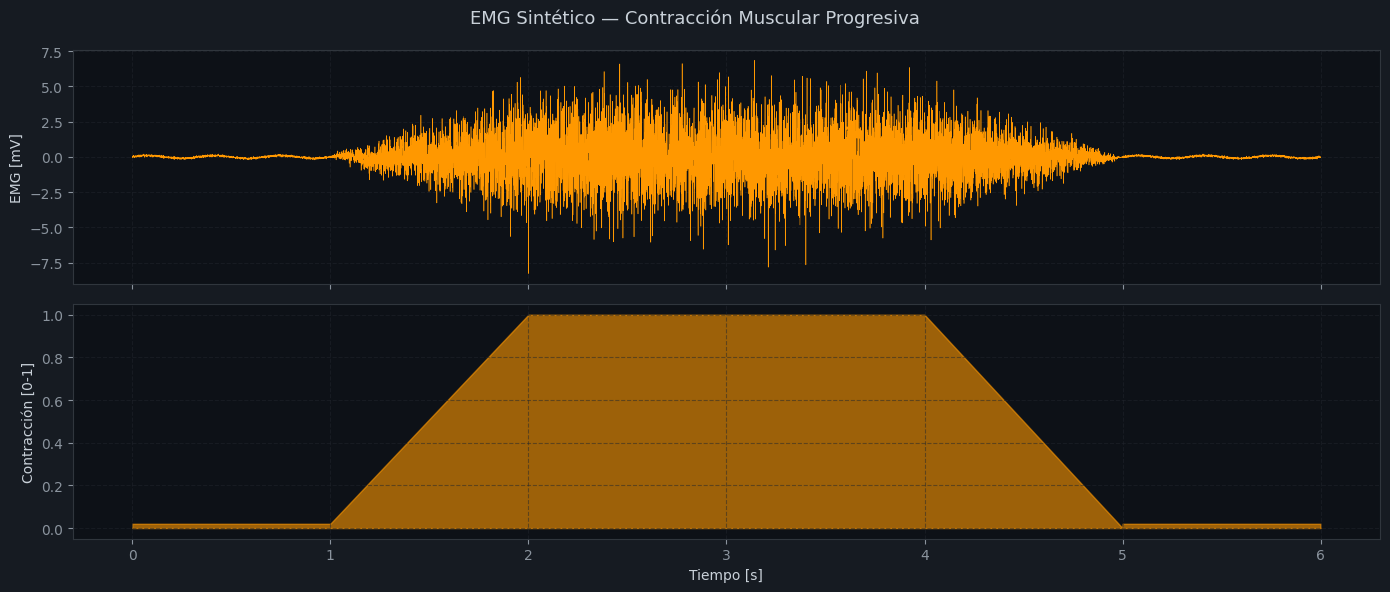

In [17]:
def emg_sintetico(t, contraccion=0.5, fs=2000):
    """Genera una señal EMG sintética.
    
    Modela el EMG como ruido de alta frecuencia modulado en amplitud,
    lo que representa la suma de potenciales de unidad motora (PUMs).
    
    Args:
        t (float): tiempo en segundos
        contraccion (float): nivel de contracción muscular [0.0 a 1.0]
        fs (int): frecuencia de muestreo [Hz]
        
    Returns:
        float: voltaje EMG en mV
    """
    # El EMG es esencialmente ruido aleatorio de alta frecuencia
    # cuya amplitud (RMS) es proporcional a la fuerza de contracción
    amplitud = contraccion * 2.0   # mV
    señal = random.gauss(0, amplitud)
    
    # Componente de baja frecuencia (artefacto de movimiento)
    señal += 0.1 * math.sin(2 * math.pi * 3 * t)
    return señal


# Simular contracción progresiva: reposo → contracción → reposo
FS_EMG = 2000
dur_emg = 6
t_emg = [i / FS_EMG for i in range(FS_EMG * dur_emg)]

def nivel_contraccion(t):
    """Perfil de contracción muscular con rampa de subida y bajada."""
    if t < 1:     return 0.02   # reposo
    elif t < 2:   return 0.02 + 0.98 * (t - 1)   # rampa de subida
    elif t < 4:   return 1.0    # contracción máxima
    elif t < 5:   return 1.0 - (t - 4)            # rampa de bajada
    else:         return 0.02   # reposo

emg_señal = [emg_sintetico(t, nivel_contraccion(t)) for t in t_emg]
contracciones = [nivel_contraccion(t) for t in t_emg]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('EMG Sintético — Contracción Muscular Progresiva', fontsize=13)

ax1.plot(t_emg, emg_señal, color='#ff9800', linewidth=0.4)
ax1.set_ylabel('EMG [mV]')
ax1.grid(True)

ax2.fill_between(t_emg, contracciones, alpha=0.6, color='#ff9800')
ax2.set_ylabel('Contracción [0-1]')
ax2.set_xlabel('Tiempo [s]')
ax2.grid(True)

plt.tight_layout()
plt.show()

## 4. Presión Arterial y SpO₂

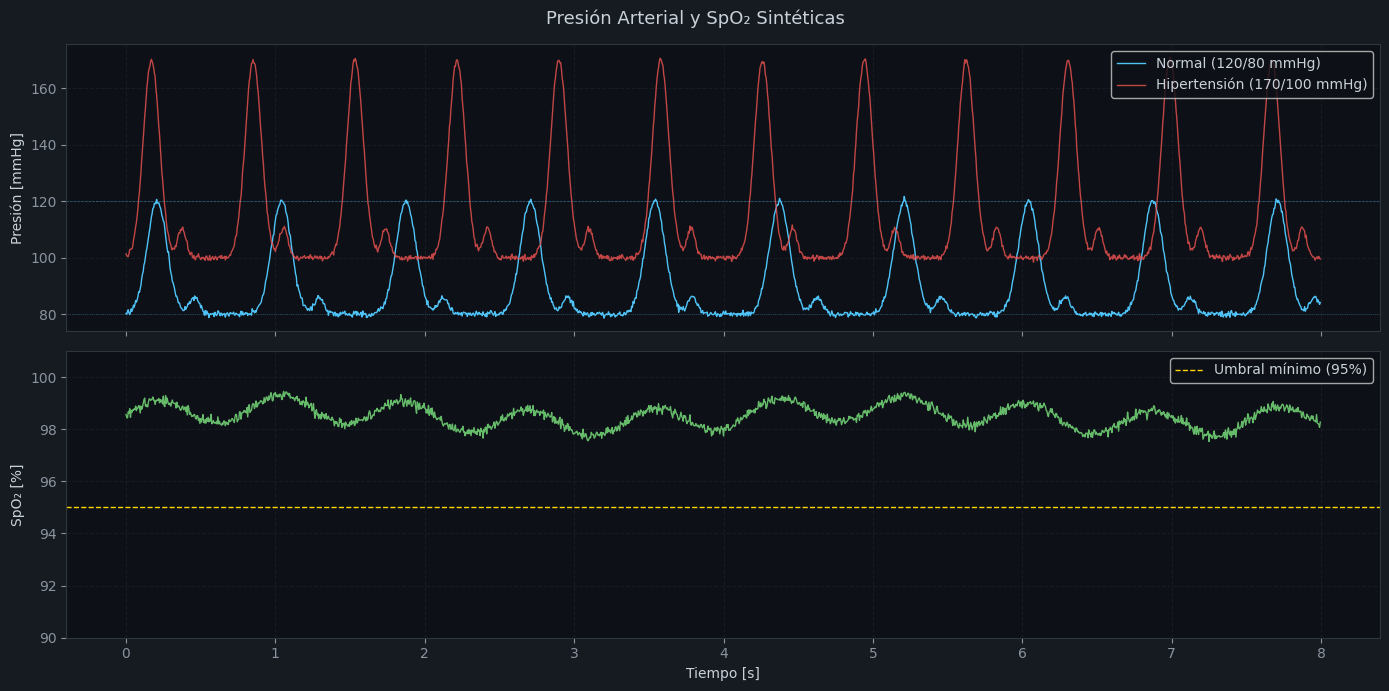

In [18]:
def presion_arterial(t, sistolica=120, diastolica=80, fc=72):
    """Genera una onda de presión arterial sintética.
    
    La onda de presión tiene un pico sistólico pronunciado
    y una caída diastólica con una pequeña muesca dicrota.
    
    Args:
        t (float): tiempo en segundos
        sistolica (float): presión sistólica [mmHg]
        diastolica (float): presión diastólica [mmHg]
        fc (float): frecuencia cardíaca [lpm]
        
    Returns:
        float: presión arterial en mmHg
    """
    periodo = 60.0 / fc
    t_norm = (t % periodo) / periodo
    
    # Pico sistólico
    pico = (sistolica - diastolica) * gaussiana(t_norm, 1.0, 0.25, 0.08)
    # Muesca dicrota (rebote de la válvula aórtica)
    muesca = (sistolica - diastolica) * 0.15 * gaussiana(t_norm, 1.0, 0.55, 0.04)
    
    return diastolica + pico + muesca + random.gauss(0, 0.5)


def spo2_ppg(t, spo2_media=98.5, fc=72):
    """Genera una señal PPG (fotopletismografía) sintética para SpO₂.
    
    Args:
        t (float): tiempo en segundos
        spo2_media (float): SpO₂ media [%]
        fc (float): frecuencia cardíaca [lpm]
        
    Returns:
        float: SpO₂ estimada [%]
    """
    periodo = 60.0 / fc
    # Variación pulsátil del SpO₂ (muy pequeña en condiciones normales)
    variacion = 0.5 * math.sin(2 * math.pi * t / periodo)
    # Modulación respiratoria lenta
    modulacion_resp = 0.3 * math.sin(2 * math.pi * 0.25 * t)   # 15 resp/min
    return spo2_media + variacion + modulacion_resp + random.gauss(0, 0.1)


FS_PA = 200
dur_pa = 8
t_pa = [i / FS_PA for i in range(FS_PA * dur_pa)]

pa_normal = [presion_arterial(t, 120, 80, 72) for t in t_pa]
pa_hiper  = [presion_arterial(t, 170, 100, 88) for t in t_pa]   # hipertensión
spo2      = [spo2_ppg(t) for t in t_pa]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Presión Arterial y SpO₂ Sintéticas', fontsize=13)

ax1.plot(t_pa, pa_normal, color='#4fc3f7', linewidth=1.0, label='Normal (120/80 mmHg)')
ax1.plot(t_pa, pa_hiper, color='#ef5350', linewidth=1.0, label='Hipertensión (170/100 mmHg)', alpha=0.8)
ax1.axhline(120, color='#4fc3f7', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axhline(80,  color='#4fc3f7', linewidth=0.5, linestyle=':', alpha=0.5)
ax1.set_ylabel('Presión [mmHg]')
ax1.legend(loc='upper right')
ax1.grid(True)

ax2.plot(t_pa, spo2, color='#66bb6a', linewidth=1.0)
ax2.axhline(95, color='#ffd700', linewidth=1, linestyle='--', label='Umbral mínimo (95%)')
ax2.set_ylabel('SpO₂ [%]')
ax2.set_xlabel('Tiempo [s]')
ax2.set_ylim(90, 101)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---

## 🧪 Ejercicios

**Ejercicio 1 — Taquicardia vs. Bradicardia:**  
Genera y grafica en la misma figura tres ECGs de 5 segundos:
- Bradicardia: FC = 45 lpm
- Normal: FC = 72 lpm  
- Taquicardia: FC = 130 lpm

**Ejercicio 2 — Transición de estados EEG:**  
Simula una transición de 12 segundos: 3s sueño → 3s relajado → 3s alerta → 3s concentrado.  
Pista: cambia los parámetros de `eeg_sintetico` según el tiempo actual.

**Ejercicio 3 — EMG de fuerza isométrica:**  
Modifica `emg_sintetico` para que el nivel de contracción sea proporcional a una fuerza aplicada.  
Calcula el **valor RMS** de la señal EMG en ventanas de 100 ms.

**Ejercicio 4 — Índice de perfusión:**  
El índice de perfusión (PI) es `(componente AC / componente DC) × 100`.  
Calcula el PI de la señal PPG generada. Valores normales: 0.02% – 20%.

---

## 📖 Resumen

- Una señal digital = lista de muestras tomadas a `fs` muestras/segundo
- ECG: 5 ondas gaussianas (P, Q, R, S, T) que se repiten con cada latido
- EEG: suma de sinusoides en distintas bandas (δ θ α β γ) según estado cognitivo
- EMG: ruido de alta frecuencia cuya amplitud refleja la fuerza de contracción
- Presión arterial: onda pulsátil con pico sistólico y nivel diastólico basal
- Teorema de Nyquist: `fs ≥ 2 × f_máx` para capturar correctamente la señal

➡️ **Siguiente: `01_procesamiento_señales.ipynb`** — Filtrado y análisis frecuencial